# Order flow imbalance: does signed volume predict returns?

Order flow imbalance (OFI) — the excess of buyer-initiated over
seller-initiated volume — is the workhorse microstructure signal: strongly
correlated with contemporaneous price moves, and (in real markets, at short
horizons) mildly predictive of the next move. This recipe builds both
flavors on h5i-db:

1. **trade OFI** — audit signing rules against ground truth (Lee-Ready via
   an ASOF join to the prevailing quote, tick test as fallback), sign the
   tape, bucket signed volume per minute,
2. **quote OFI** (Cont, Kukanov & Stoikov 2014) — order-book pressure from
   changes in best bid/ask prices and sizes, via `lag()` windows,
3. an honest look at contemporaneous vs *predictive* correlation with
   1-minute returns.

In [1]:
import numpy as np
import pandas as pd
import pyarrow as pa

import h5i_db
import cookbook_utils as cu

db = h5i_db.Database(cu.fresh_db("alpha_ofi"), create=True)

## 1. A quote stream, and a tape printed off it

One generator caveat first: `make_trades`' prints follow a random walk
that is only loosely coupled to `make_quotes`' mids, which would make
quote-based trade signing meaningless. So we keep the synthetic quote
stream and *print our own tape off it*, the way a matching engine would:
a random 25% of quote updates trigger a trade 1-50 ms later, buyers lift
the offer, sellers hit the bid, with the true aggressor side recorded.
The tape is price-consistent with the quotes by construction, and every
signing rule below can be scored against ground truth — a luxury real
data never affords.

In [2]:
quotes = cu.make_quotes(symbols=["AAPL", "MSFT"], days=2)
q = quotes.to_pandas()

rng = np.random.default_rng(21)
picks = q[rng.random(len(q)) < 0.25].copy()
side = rng.choice(np.array([1, -1]), size=len(picks))
picks["price"] = np.where(side > 0, picks["ask"], picks["bid"])
picks["ts"] = (
    picks["ts"] + pd.to_timedelta(rng.integers(1_000, 50_000, len(picks)), unit="us")
).astype("datetime64[us, UTC]")
picks["size"] = np.maximum(100, (rng.lognormal(4.0, 1.2, len(picks)) // 100 * 100)).astype("int64")
picks["side"] = np.where(side > 0, "B", "S")

trade_schema = pa.schema(
    [
        pa.field("ts", pa.timestamp("us", tz="UTC"), nullable=False),
        pa.field("symbol", pa.string()),
        pa.field("price", pa.float64()),
        pa.field("size", pa.int64()),
        pa.field("side", pa.string()),
    ]
)
trades_df = picks[["ts", "symbol", "price", "size", "side"]].sort_values(["ts", "symbol"])
trades = pa.Table.from_pandas(trades_df, preserve_index=False).cast(trade_schema)

db.create_table("quotes", quotes.schema, time_column="ts", sort_key=["ts", "symbol"])
db.append("quotes", quotes, note="2-day synthetic NBBO")
db.create_table("trades", trade_schema, time_column="ts", sort_key=["ts", "symbol"])
db.append("trades", trades, note="tape printed off the quote stream")
print({t: len(db.read(t)) for t in db.tables()})

{'quotes': 237391, 'trades': 59090}


## 2. Audit the signing rules on a QA window

Lee-Ready says: above the prevailing mid → buy, below → sell, at mid →
fall back to the tick test (uptick → buy). The prevailing-quote lookup is
`asof_join(..., 'backward', 5_000_000)`: the latest quote at most 5
seconds old, per symbol, tolerance in raw microseconds.

We run the audit on a midday 15-minute window, carved out with time-ranged
`db.read` calls (raw microsecond bounds, pruned at the segment level) and
stored as small workbench tables. Windowing is not just audit hygiene: the
current build's `asof_join` only handles inputs that fit in one storage
batch (~8k rows per side) and silently truncates beyond that. So we keep
both sides small, assert the join returns exactly one row per trade, and
cross-check the attached quotes against `pandas.merge_asof`.

In [3]:
w0 = int(pd.Timestamp("2026-06-01 16:00", tz="UTC").value // 1000)
w1 = int(pd.Timestamp("2026-06-01 16:15", tz="UTC").value // 1000)

trades_w = db.read("trades", time_start=w0, time_end=w1)
quotes_w = db.read("quotes", time_start=w0 - 60_000_000, time_end=w1)  # 60s run-up
db.create_table("trades_qa", trade_schema, time_column="ts", sort_key=["ts", "symbol"])
db.append("trades_qa", trades_w, note="midday QA window")
db.create_table("quotes_qa", quotes.schema, time_column="ts", sort_key=["ts", "symbol"])
db.append("quotes_qa", quotes_w, note="midday QA window + run-up")
print(f"QA window: {len(trades_w):,} trades, {len(quotes_w):,} quotes")

audit = db.sql(
    """
    WITH tq AS (
        SELECT ts, symbol, price, size, side, bid, ask,
               (bid + ask) / 2 AS mid,
               lag(price) OVER (PARTITION BY symbol ORDER BY ts) AS prev_px
        FROM asof_join('trades_qa', 'quotes_qa', 'ts', 'ts', 'symbol', 'backward', 5000000)
    )
    SELECT ts, symbol, mid,
           CASE WHEN price > mid THEN 1 WHEN price < mid THEN -1
                WHEN price > prev_px THEN 1 WHEN price < prev_px THEN -1 ELSE 0 END AS lr_sign,
           CASE WHEN price > prev_px THEN 1 WHEN price < prev_px THEN -1 ELSE 0 END AS tick_sign,
           CASE WHEN side = 'B' THEN 1 ELSE -1 END AS true_sign
    FROM tq
    ORDER BY ts, symbol
    """
).to_pandas()
assert len(audit) == len(trades_w), "asof_join must return one row per trade"

# cross-check the ASOF lookup itself against pandas.merge_asof
ref = pd.merge_asof(
    trades_w.to_pandas().sort_values("ts"),
    quotes_w.to_pandas().sort_values("ts").assign(mid_ref=lambda d: (d["bid"] + d["ask"]) / 2),
    on="ts",
    by="symbol",
    tolerance=pd.Timedelta("5s"),
)
chk = audit.sort_values("ts").reset_index(drop=True)
assert np.allclose(chk["mid"], ref["mid_ref"], equal_nan=True), "asof mismatch vs pandas"
print("asof_join validated against pandas.merge_asof")

for rule in ("lr_sign", "tick_sign"):
    scored = audit[audit[rule] != 0]
    acc = (scored[rule] == scored["true_sign"]).mean()
    print(f"  {rule:9s}: {acc:.1%} accuracy vs true aggressor side ({len(scored):,} classified)")

QA window: 438 trades, 1,884 quotes
asof_join validated against pandas.merge_asof
  lr_sign  : 98.1% accuracy vs true aggressor side (432 classified)
  tick_sign: 72.4% accuracy vs true aggressor side (377 classified)


On a price-consistent tape, Lee-Ready earns its reputation: the quote rule
is nearly perfect (errors come from quotes that updated in the 1-50 ms
between quote and print), while the pure tick test trails well behind —
the same ordering seen on real TAQ, where Lee-Ready scores ~85%.

## 3. Sign the full tape

The audited quote rule needs the trade-quote ASOF at full scale, which the
current build's batch limit rules out — production answer: loop the join
over windows like the one above. For this recipe the tick test (a pure
`lag()` window over `trades`, no alignment needed) is accurate enough to
carry the OFI study, and we keep the generator's true side as an oracle
upper bound. The signed tape is persisted as a first-class table: signing
is expensive enough that you want it done once, committed, and versioned.

In [4]:
signed = db.sql(
    """
    WITH t AS (
        SELECT ts, symbol, price, size, side,
               lag(price) OVER (PARTITION BY symbol ORDER BY ts) AS prev_px
        FROM trades
    )
    SELECT ts, symbol, price, size,
           CASE WHEN price > prev_px THEN 1 WHEN price < prev_px THEN -1 ELSE 0 END AS tick_sign,
           CASE WHEN side = 'B' THEN 1 ELSE -1 END AS true_sign
    FROM t
    ORDER BY ts, symbol
    """
).to_arrow()

full = signed.to_pandas()
scored = full[full["tick_sign"] != 0]
print(f"full tape: {(scored['tick_sign'] == scored['true_sign']).mean():.1%} tick-test accuracy on {len(scored):,} prints")

full tape: 76.8% tick-test accuracy on 47,957 prints


In [5]:
signed_schema = pa.schema(
    [
        pa.field("ts", pa.timestamp("us", tz="UTC"), nullable=False),
        pa.field("symbol", pa.string()),
        pa.field("price", pa.float64()),
        pa.field("size", pa.int64()),
        pa.field("tick_sign", pa.int32()),
        pa.field("true_sign", pa.int32()),
    ]
)
db.create_table("signed_trades", signed_schema, time_column="ts", sort_key=["ts", "symbol"])
db.append("signed_trades", signed.cast(signed_schema), note="tick-test + oracle signs")

{'table': 'signed_trades',
 'sequence': 1,
 'op': 'append',
 'rows_total': 59090,
 'segments_total': 1,
 'segments_added': 1,
 'segments_deduped': 0,
 'committed_at_ns': 1784776180486742896}

## 4. Trade OFI per minute

One `time_bucket` aggregation: signed buy/sell volume, normalized
imbalance `(buys - sells) / total`, and the bucket's closing print via the
`last_value(... ORDER BY ts)` idiom.

In [6]:
trade_ofi = db.sql(
    """
    SELECT time_bucket('1m', ts) AS bar, symbol,
           sum(CASE WHEN tick_sign > 0 THEN size ELSE 0 END) AS buy_vol,
           sum(CASE WHEN tick_sign < 0 THEN size ELSE 0 END) AS sell_vol,
           sum(CASE WHEN true_sign > 0 THEN size ELSE -size END) AS oracle_net,
           sum(size) AS volume,
           last_value(price ORDER BY ts) AS close
    FROM signed_trades
    GROUP BY bar, symbol
    ORDER BY bar, symbol
    """
).to_pandas()
trade_ofi["ofi"] = (trade_ofi["buy_vol"] - trade_ofi["sell_vol"]) / trade_ofi["volume"]
trade_ofi["ofi_oracle"] = trade_ofi["oracle_net"] / trade_ofi["volume"]
trade_ofi.head(4)

,bar,symbol,buy_vol,sell_vol,oracle_net,volume,close,ofi,ofi_oracle
0,2026-06-01 13:30:00+00:00,AAPL,3200,5100,-1000,11800,86.20,-0.161017,-0.084746
1,2026-06-01 13:30:00+00:00,MSFT,9400,6100,2400,17000,219.75,0.194118,0.141176
2,2026-06-01 13:31:00+00:00,AAPL,5800,4300,-2400,13000,86.17,0.115385,-0.184615
3,2026-06-01 13:31:00+00:00,MSFT,9300,10900,-200,22400,219.77,-0.071429,-0.008929


## 5. Quote OFI (Cont et al.)

Book-pressure OFI needs *changes* at the best: a bid price rising (or size
growing at an unchanged bid) adds buy pressure; the mirror on the ask side
subtracts. That is four `lag()` comparisons per quote — pure SQL window
machinery — summed per minute, with the bucket's closing mid for returns.

In [7]:
quote_ofi = db.sql(
    """
    WITH q AS (
        SELECT ts, symbol, bid, ask, bid_size, ask_size,
               lag(bid)      OVER w AS pb,  lag(ask)      OVER w AS pa,
               lag(bid_size) OVER w AS pbs, lag(ask_size) OVER w AS pas
        FROM quotes
        WINDOW w AS (PARTITION BY symbol ORDER BY ts)
    )
    SELECT time_bucket('1m', ts) AS bar, symbol,
           sum(  CASE WHEN bid >= pb THEN bid_size ELSE 0 END
               - CASE WHEN bid <= pb THEN pbs      ELSE 0 END
               - CASE WHEN ask <= pa THEN ask_size ELSE 0 END
               + CASE WHEN ask >= pa THEN pas      ELSE 0 END) AS qofi,
           last_value((bid + ask) / 2 ORDER BY ts) AS mid_close
    FROM q
    WHERE pb IS NOT NULL
    GROUP BY bar, symbol
    ORDER BY bar, symbol
    """
).to_pandas()
quote_ofi.head(4)

,bar,symbol,qofi,mid_close
0,2026-06-01 13:30:00+00:00,AAPL,-11900,86.205
1,2026-06-01 13:30:00+00:00,MSFT,24600,219.745
2,2026-06-01 13:31:00+00:00,AAPL,-1700,86.150
3,2026-06-01 13:31:00+00:00,MSFT,27500,219.775


## 6. Contemporaneous vs predictive

The question that matters: does this minute's OFI tell you about *this*
minute's return (mechanical) or the *next* minute's (alpha)? We compute
both correlations per symbol, per estimator. Returns are within-session
only (`shift` inside each symbol/day, so no overnight artifacts).

In [8]:
def bucket_corrs(frame, ofi_col, px_col):
    rows = []
    frame = frame.copy()
    frame["day"] = frame["bar"].dt.date
    for (sym, _), g in frame.groupby(["symbol", "day"]):
        g = g.sort_values("bar")
        frame.loc[g.index, "ret"] = g[px_col].pct_change()
        frame.loc[g.index, "ret_next"] = g[px_col].pct_change().shift(-1)
    for sym, g in frame.groupby("symbol"):
        g = g.dropna(subset=["ret", "ret_next"])
        rows.append(
            {
                "symbol": sym,
                "n_buckets": len(g),
                "corr_same_min": g[ofi_col].corr(g["ret"]),
                "corr_next_min": g[ofi_col].corr(g["ret_next"]),
            }
        )
    return pd.DataFrame(rows)

results = pd.concat(
    [
        bucket_corrs(trade_ofi, "ofi", "close").assign(estimator="trade OFI (tick test)"),
        bucket_corrs(trade_ofi, "ofi_oracle", "close").assign(estimator="trade OFI (oracle)"),
        bucket_corrs(quote_ofi, "qofi", "mid_close").assign(estimator="quote OFI (Cont)"),
    ]
)[["estimator", "symbol", "n_buckets", "corr_same_min", "corr_next_min"]]
results.round(3)

,estimator,symbol,n_buckets,corr_same_min,corr_next_min
0,trade OFI (tick test),AAPL,776,0.503,0.007
1,trade OFI (tick test),MSFT,776,0.453,-0.109
0,trade OFI (oracle),AAPL,776,0.077,-0.055
1,trade OFI (oracle),MSFT,776,0.068,-0.070
0,quote OFI (Cont),AAPL,776,0.638,-0.036
1,quote OFI (Cont),MSFT,776,0.494,-0.007


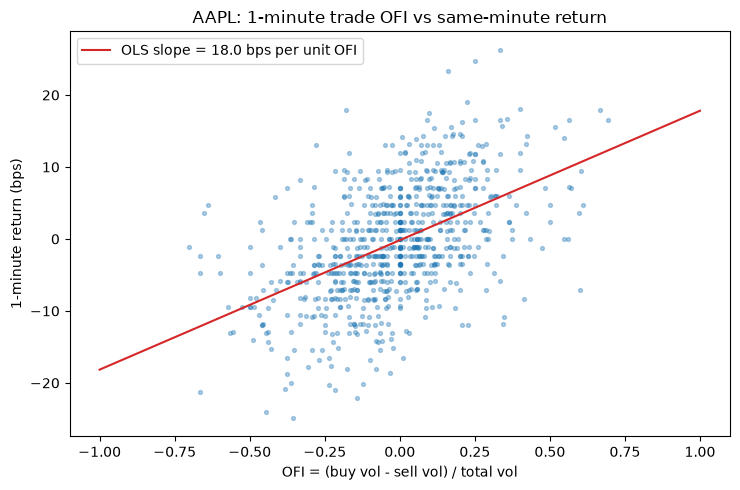

In [9]:
import matplotlib.pyplot as plt

sym = "AAPL"
g = trade_ofi[trade_ofi["symbol"] == sym].copy()
g["day"] = g["bar"].dt.date
g["ret"] = g.groupby("day")["close"].pct_change()
g = g.dropna(subset=["ret"])

fig, ax = plt.subplots(figsize=(7.5, 5))
ax.scatter(g["ofi"], g["ret"] * 1e4, s=8, alpha=0.35, color="tab:blue")
b, a = np.polyfit(g["ofi"], g["ret"] * 1e4, 1)
xs = np.linspace(-1, 1, 50)
ax.plot(xs, a + b * xs, color="tab:red", lw=1.5, label=f"OLS slope = {b:.1f} bps per unit OFI")
ax.set_title(f"{sym}: 1-minute trade OFI vs same-minute return")
ax.set_xlabel("OFI = (buy vol - sell vol) / total vol")
ax.set_ylabel("1-minute return (bps)")
ax.legend()
fig.tight_layout()

Three honest lessons in one table:

- **Quote OFI** shows the textbook contemporaneous link (~0.5-0.6): book
  pressure and same-minute mid moves are near-mechanically related.
- **Trade OFI with tick-test signs** also reads ~0.5 contemporaneous —
  but the **oracle** row exposes most of that as circular. With *true*
  aggressor signs the correlation drops to ~0.07: in this market the mid
  is an exogenous random walk, flow has no price impact, and true signed
  volume relates to the minute's return only through the bounce of the
  closing print. The tick rule manufactures the rest by deriving signs
  from the very price changes we then correlate against. On real data,
  where flow does move price, the oracle-equivalent number would be
  solidly positive — the comparison is how you learn to ask.
- **Predictive** correlations sit near zero with a negative tilt for
  trade OFI: bid-ask bounce means a buy-heavy minute tends to close at
  the ask and mean-revert a touch. Even perfect signs would not help —
  there is no flow-to-future-price causality here to find, and the
  pipeline correctly finds none.

On real tick data quote OFI does carry short-horizon predictive power —
but the reality check applies before calling it alpha: the effect lives at
seconds-to-minutes horizons in size-constrained depth, and capturing a
~1 bp move costs you the spread plus fees. OFI signals are best understood
as execution-layer inputs (when to cross, when to post), not standalone
strategies.

## Takeaways

- `asof_join(..., 'backward', tolerance)` is the prevailing-quote lookup,
  and time-ranged `db.read(time_start=, time_end=)` carves QA windows in
  O(window). Current-build caveat: keep both ASOF inputs within one
  storage batch (~8k rows) and assert one output row per left row —
  larger inputs truncate silently. Cross-checking against
  `pandas.merge_asof` costs three lines and buys certainty.
- Signing rules are CASE expressions over that join plus `lag()` windows;
  persisting the result as a `signed_trades` table means the pass runs
  once, and every downstream study reads versioned, committed signs.
- Both OFI flavors reduce to one `time_bucket` GROUP BY each — with
  `last_value(... ORDER BY ts)` giving bucket closes without self-joins.
- Honest nulls matter: solid contemporaneous correlations alongside
  predictive correlations ≈ 0 (even with oracle signs) is the signature
  of a mechanical, not exploitable, relationship.

In [10]:
db.close()